# Hypothesentest (durch T-Test)

## Quelle des Datensets

### Das Datenset ist ein öffentlich verfügbares Datenset für Forschungszwecke von Cortez et al. (2009).

Quelle: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis (2009).   
Modeling wine preferences by data mining from physicochemical properties.  
Decision Support Systems, 47(4), 547–553.   
Link zum Artikel: https://doi.org/10.1016/j.dss.2009.05.016  
Link zum Datenset: https://archive.ics.uci.edu/dataset/186/wine+quality  

### Alternativhypothese (H1): Die mittlere Weinqualität von Rotwein und Weißwein unterscheidet sich statistisch signifikant.

### Nullhypothese (H0): Die mittlere Weinqualität von Rotwein und Weißwein ist gleich.

### Setup (Libraries)

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

### CSV Datei einlesen

In [13]:
df = pd.read_csv("winequality_red_white.csv", sep=";") # Erstellt in lab08

### Histogramm über die Verteilung von der Qualität der Weinarten und Durschnittswert (aus lab 08)

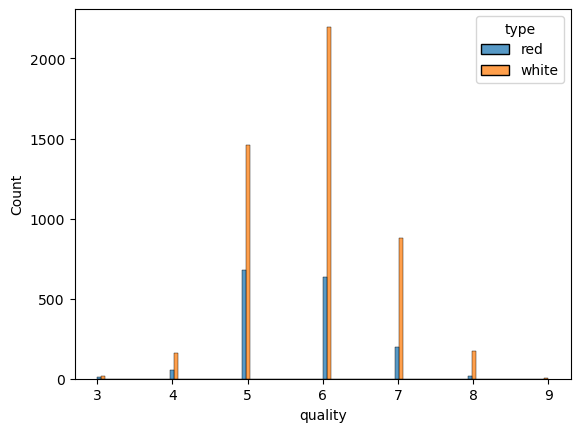

In [26]:
sns.histplot(data=df, x='quality', hue='type', multiple='dodge') # Histogramm, Verteilung der Qualität von Rod- und Weißwein
plt.show()

In [61]:
df.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [63]:
print("Mittlere Weinqualität von Rot- und Weißwein unterschiedlich, aber ist der Mittelwertunterschied statistisch signifikant? T-Test notwendig!")

Mittlere Weinqualität von Rot- und Weißwein unterschiedlich, aber ist der Mittelwertunterschied statistisch signifikant? T-Test notwendig!


### T-Test Auswahl

#### Ein unabhängiger, zweiseitiger t-Test (Welch’s t-Test) ist hier sinnvoll, weil ich die mittlere Qualität zweier unabhängiger Gruppen (Rot- vs. Weißwein) vergleichen will, ohne vorher eine Richtung des Unterschieds anzunehmen und die Varianzen unterschiedlich sein könnten.

In [46]:
# Gruppen erstellen
red_quality = df[df['type'] == 'red']['quality']
white_quality = df[df['type'] == 'white']['quality']

# Welch's t-Test (unabhängige Gruppen, Varianzen können unterschiedlich sein)
t_stat, p_value = ttest_ind(red_quality, white_quality, equal_var=False)

# Ergebnisse ausgeben
print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

if p_value < 0.05:
    print("Der Unterschied der mittleren Qualität ist statistisch signifikant.")
else:
    print("Kein signifikanter Unterschied der mittleren Qualität.")

t-Statistik: -10.149363059143164
p-Wert: 8.168348870049682e-24
Der Unterschied der mittleren Qualität ist statistisch signifikant.


### Schlussfolgerung/ Konklusion

In [59]:
print("Da der p-Wert des Welch’s t-Tests kleiner als 0,05 ist, wird die Nullhypothese abgelehnt. \
Die Alternativhypothese ist damit bestätigt: Die mittlere Weinqualität von Rotwein und Weißwein \
unterscheidet sich statistisch signifikant.")

Da der p-Wert des Welch’s t-Tests kleiner als 0,05 ist, wird die Nullhypothese abgelehnt. Die Alternativhypothese ist damit bestätigt: Die mittlere Weinqualität von Rotwein und Weißwein unterscheidet sich statistisch signifikant.


In [65]:
print("Der Unterschied in den Mittelwerten (Rot ~5.64, Weiß ~5.88) ist so groß, \
dass er sehr wahrscheinlich nicht durch Zufall zustande kam. Allerdings ist der Unterschied nur 0,24 Punkte\
auf einer von 0–10-Skala sehr klein. Das heißt, für einen normalen Weintrinker ist der Unterschied wahrscheinlich kaum wahrnehmbar.")

Der Unterschied in den Mittelwerten (Rot ~5.64, Weiß ~5.88) ist so groß, dass er sehr wahrscheinlich nicht durch Zufall zustande kam. Allerdings ist der Unterschied nur 0,24 Punkteauf einer von 0–10-Skala sehr klein. Das heißt, für einen normalen Weintrinker ist der Unterschied wahrscheinlich kaum wahrnehmbar.
